# Protein Identification Assessment

Expected input files in the same folder as this notebook:

- `variants_tmt.tsv` — raw/annotation table from the Variants TMT dataset.
- One top-peptide file, preferably one of:
  - `top50_statistical_peptides.tsv`
  - `checkpoint4_selected_peptides_top200.tsv`
  - `peptide_statistical_tests.tsv`

The `variants_tmt.ipynb` notebook generates `top50_statistical_peptides.tsv`, so that is the default file used here.

## Step 0 — Imports and configuration

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import networkx as nx
    HAS_NETWORKX = True
except ImportError:
    HAS_NETWORKX = False
    print("networkx is not installed; the bipartite graph cell will be skipped unless you install it.")

DATA_DIR = Path(".")
RAW_VARIANTS_FILE = DATA_DIR / "variants_tmt.tsv"

TOP_PEPTIDE_CANDIDATES = [
    DATA_DIR / "top50_statistical_peptides.tsv",
    DATA_DIR / "checkpoint4_selected_peptides_top200.tsv",
    DATA_DIR / "peptide_statistical_tests.tsv",
]

OUTPUT_DIR = DATA_DIR / "protein_identification_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

N_TOP_PEPTIDES = 50

## Step 1 — Load the top peptides

This uses the statistical output from the previous notebook. If multiple candidate files exist, it chooses the first one listed above.

In [2]:
def read_table_auto(path: Path) -> pd.DataFrame:
    """Read TSV/CSV using a simple delimiter guess."""
    if not path.exists():
        raise FileNotFoundError(path)
    if path.suffix.lower() in [".tsv", ".txt"]:
        return pd.read_csv(path, sep="	", low_memory=False)
    return pd.read_csv(path, low_memory=False)

existing_top_files = [p for p in TOP_PEPTIDE_CANDIDATES if p.exists()]
if not existing_top_files:
    raise FileNotFoundError(
        "Could not find a top-peptide file. Please add one of: "
        + ", ".join(str(p) for p in TOP_PEPTIDE_CANDIDATES)
    )

TOP_PEPTIDE_FILE = existing_top_files[0]
top_df = read_table_auto(TOP_PEPTIDE_FILE)
print(f"Loaded top peptide file: {TOP_PEPTIDE_FILE}")
print(f"Shape: {top_df.shape}")
display(top_df.head())

Loaded top peptide file: top50_statistical_peptides.tsv
Shape: (50, 10)


,Peptide,n_severe,n_nonsevere,mean_severe,mean_nonsevere,log2_fold_change,t_pvalue,mannwhitney_pvalue,t_fdr,mannwhitney_fdr
0,"R.[304.207]LTG(R,-19.035)GAEDSLADQAAN(K,304.20...",18,25,2.093578,0.173872,1.398001,0.034333,0.000024,0.999969,0.832764
1,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",18,25,0.782201,2.105869,-0.801337,0.000011,0.000042,0.713465,0.832764
2,"R.[304.207]SG(K,304.207)DPNHFRPAGLPE(K,304.207).Y",16,22,1.268089,0.190600,0.929789,0.002498,0.000054,0.999969,0.832764
3,"R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G",18,25,2.996334,0.342298,1.573973,0.007896,0.000057,0.999969,0.832764
4,"R.{290.175}[304.207]NE(C,57.021)FLQH(K,304.207...",14,19,0.801713,1.897051,-0.685216,0.000034,0.000057,0.713465,0.832764


## Step 2 — Detect the peptide column in the top-peptide file

The previous notebook usually saves the peptide sequence/variant identifier in a column named `Peptide`.

In [ ]:
def find_column(df: pd.DataFrame, candidates, required=True, label="column"):
    """Find the first matching column by exact or case-insensitive name."""
    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}

    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise ValueError(
            f"Could not find {label}. Tried: {candidates}. Available columns include: {cols[:30]}"
        )
    return None

TOP_PEPTIDE_COL = find_column(
    top_df,
    candidates=["Peptide", "peptide", "Modified sequence", "Modified.Sequence", "Sequence", "feature", "Feature"],
    label="top peptide column"
)

top_peptides = (
    top_df[TOP_PEPTIDE_COL]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .head(N_TOP_PEPTIDES)
    .tolist()
)

print(f"Using column `{TOP_PEPTIDE_COL}` for peptide IDs.")
print(f"Number of top peptides selected: {len(top_peptides)}")
print("First 5:")
for pep in top_peptides[:5]:
    print(" -", pep[:120])

Using column `Peptide` for peptide IDs.
Number of top peptides selected: 50
First 5:
 - R.[304.207]LTG(R,-19.035)GAEDSLADQAAN(K,304.207).W
 - R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W
 - R.[304.207]SG(K,304.207)DPNHFRPAGLPE(K,304.207).Y
 - R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G
 - R.{290.175}[304.207]NE(C,57.021)FLQH(K,304.207)DDNPNLPR.L


## Step 3 — Load raw Variants TMT metadata

This raw file is needed because it should contain the peptide annotations and protein mapping columns. The earlier filtered matrix keeps only peptide intensity values, so it usually does **not** contain enough protein-identification metadata by itself.

In [4]:
if not RAW_VARIANTS_FILE.exists():
    raise FileNotFoundError(
        f"Missing {RAW_VARIANTS_FILE}. Please place variants_tmt.tsv in the same folder as this notebook."
    )

variants = pd.read_csv(RAW_VARIANTS_FILE, sep="	", low_memory=False)
print(f"Loaded raw variants file: {RAW_VARIANTS_FILE}")
print(f"Shape: {variants.shape}")
print("First 40 columns:")
print(list(variants.columns[:40]))

Loaded raw variants file: variants_tmt.tsv
Shape: (101461, 268)
First 40 columns:
['rowid', 'ccms_row_id', 'Algorithm', 'Filename', 'Cluster_index', 'Peptide', 'Unmodified_sequence', 'Charge', '_dyn_#Intensity_for_cluster', '_dyn_#Intensity_for_unmodified_sequence', 'Num_G1_spectra_for_unmodified_sequence', 'Num_G2_spectra_for_unmodified_sequence', 'Num_G3_spectra_for_unmodified_sequence', 'Num_G4_spectra_for_unmodified_sequence', 'Num_G5_spectra_for_unmodified_sequence', 'Num_G6_spectra_for_unmodified_sequence', '_dyn_#Empty.Empty.Empty..Empty.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC1.Healthy..HC1.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC10.Healthy..HC10.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC12.Healthy..HC12.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC13.Healthy..HC13.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC17.Healthy..HC17.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC19.Healthy..HC19.1_intensity_for_unm

## Step 4 — Detect peptide and protein annotation columns

This cell tries to automatically detect common protein-mapping columns. If the guesses are wrong, manually edit `RAW_PEPTIDE_COL`, `PROTEIN_ACCESSION_COL`, and `PROTEIN_NAME_COL`.

In [ ]:
RAW_PEPTIDE_COL = find_column(
    variants,
    candidates=["Peptide", "peptide", "Modified sequence", "Modified.Sequence", "Sequence", "Stripped.Sequence"],
    label="raw peptide column"
)

accession_candidates = [
    "Protein", "Proteins", "Protein IDs", "Protein.IDs", "Protein Accessions", "Protein.Accessions",
    "UniProt", "UniProtKB", "Uniprot", "Accession", "Protein accession", "Protein group IDs",
    "Leading razor protein", "Leading.razor.protein", "Majority protein IDs"
]

name_candidates = [
    "Protein names", "Protein.Names", "Protein name", "Protein.Name", "Gene names", "Gene.Names",
    "Genes", "Gene", "Description", "Fasta headers", "Fasta.Headers"
]

PROTEIN_ACCESSION_COL = find_column(variants, accession_candidates, required=False, label="protein accession column")
PROTEIN_NAME_COL = find_column(variants, name_candidates, required=False, label="protein name column")

print(f"Raw peptide column: {RAW_PEPTIDE_COL}")
print(f"Protein accession column guess: {PROTEIN_ACCESSION_COL}")
print(f"Protein name/description column guess: {PROTEIN_NAME_COL}")

if PROTEIN_ACCESSION_COL is None:
    possible = [c for c in variants.columns if re.search(r"protein|uniprot|accession|gene", str(c), re.I)]
    print("Could not automatically detect a protein accession column.")
    print("Possible annotation columns:")
    print(possible[:80])
    raise ValueError("Please manually set PROTEIN_ACCESSION_COL to the correct column name and rerun.")

Raw peptide column: Peptide
Protein accession column guess: Proteins
Protein name/description column guess: None


## Step 5 — Match top peptides to protein annotations

This creates a table linking each important peptide/variant to its associated protein accession(s).

In [ ]:
metadata_cols = [RAW_PEPTIDE_COL, PROTEIN_ACCESSION_COL]
if PROTEIN_NAME_COL is not None:
    metadata_cols.append(PROTEIN_NAME_COL)
metadata_cols = list(dict.fromkeys(metadata_cols))

metadata = variants[metadata_cols].copy()
metadata[RAW_PEPTIDE_COL] = metadata[RAW_PEPTIDE_COL].astype(str)

matched = metadata[metadata[RAW_PEPTIDE_COL].isin(top_peptides)].copy()

rank_map = {pep: i + 1 for i, pep in enumerate(top_peptides)}
matched["top_peptide_rank"] = matched[RAW_PEPTIDE_COL].map(rank_map)
matched = matched.sort_values("top_peptide_rank")

print(f"Top peptides requested: {len(top_peptides)}")
print(f"Top peptides matched in raw metadata: {matched[RAW_PEPTIDE_COL].nunique()}")

missing = [p for p in top_peptides if p not in set(matched[RAW_PEPTIDE_COL])]
if missing:
    print(f"Warning: {len(missing)} top peptides were not matched in the raw metadata.")
    print("First few missing peptides:")
    for pep in missing[:10]:
        print(" -", pep[:120])

display(matched.head(10))

Top peptides requested: 50
Top peptides matched in raw metadata: 50


,Peptide,Proteins,top_peptide_rank
85289,"R.[304.207]LTG(R,-19.035)GAEDSLADQAAN(K,304.20...",sp|P0DJI9|SAA2_HUMAN,1
3035,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",sp|P02787|TRFE_HUMAN,2
12246,"R.[304.207]SG(K,304.207)DPNHFRPAGLPE(K,304.207).Y",sp|P0DJI8|SAA1_HUMAN; tr|E9PQD6|E9PQD6_HUMAN,3
12654,"R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G",sp|P0DJI8|SAA1_HUMAN; sp|P0DJI9-2|SAA2_HUMAN; ...,4
70341,"R.{290.175}[304.207]NE(C,57.021)FLQH(K,304.207...",sp|P02768-3|ALBU_HUMAN; sp|P02768|ALBU_HUMAN; ...,5
74801,"R.[304.207](F,-13.032)(K,304.207)DLGEENF(K,304...",sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...,6
85284,"R.[304.207](L,285.173)TGRGAEDSLADQAAN(K,304.20...",sp|P0DJI9|SAA2_HUMAN,7
59963,"K.[304.207](C,348.19)(C,57.021)AAADPHE(C,57.02...",sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...,8
24181,"K.[304.207](V,290.171)DNALQSGNSQESVTEQDS(K,304...",sp|P01834|IGKC_HUMAN; tr|A0A5H1ZRQ3|A0A5H1ZRQ3...,9
56123,"Q.[200.048]TALVELV(K,304.207).H",sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...,10


## Step 6 — Parse protein mappings and determine unique vs ambiguous mappings

A peptide is treated as **uniquely mapped** if the protein accession field contains exactly one protein accession. A peptide is treated as **ambiguous/shared** if it maps to more than one accession.

In [ ]:
def split_proteins(value):
    """Split protein accession strings that may use semicolon, comma, pipe, or whitespace separators."""
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() in {"nan", "none"}:
        return []

    parts = re.split(r"[;,]", s)

    if len(parts) == 1 and re.search(r"\s", s) and not re.search(r"\|", s):
        parts = re.split(r"\s+", s)

    cleaned = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        cleaned.append(p)
    return list(dict.fromkeys(cleaned))

matched["mapped_proteins"] = matched[PROTEIN_ACCESSION_COL].apply(split_proteins)
matched["num_mapped_proteins"] = matched["mapped_proteins"].apply(len)
matched["unique_mapping"] = matched["num_mapped_proteins"].eq(1)
matched["main_protein"] = matched["mapped_proteins"].apply(lambda xs: xs[0] if xs else np.nan)

peptide_protein_table = matched.drop_duplicates(subset=[RAW_PEPTIDE_COL]).copy()

cols = ["top_peptide_rank", RAW_PEPTIDE_COL, PROTEIN_ACCESSION_COL, "num_mapped_proteins", "unique_mapping", "main_protein"]
if PROTEIN_NAME_COL is not None:
    cols.insert(3, PROTEIN_NAME_COL)

peptide_protein_table = peptide_protein_table[cols].sort_values("top_peptide_rank")

display(peptide_protein_table.head(20))

,top_peptide_rank,Peptide,Proteins,num_mapped_proteins,unique_mapping,main_protein
85289,1,"R.[304.207]LTG(R,-19.035)GAEDSLADQAAN(K,304.20...",sp|P0DJI9|SAA2_HUMAN,1,True,sp|P0DJI9|SAA2_HUMAN
3035,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",sp|P02787|TRFE_HUMAN,1,True,sp|P02787|TRFE_HUMAN
12246,3,"R.[304.207]SG(K,304.207)DPNHFRPAGLPE(K,304.207).Y",sp|P0DJI8|SAA1_HUMAN; tr|E9PQD6|E9PQD6_HUMAN,2,False,sp|P0DJI8|SAA1_HUMAN
12654,4,"R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G",sp|P0DJI8|SAA1_HUMAN; sp|P0DJI9-2|SAA2_HUMAN; ...,8,False,sp|P0DJI8|SAA1_HUMAN
70341,5,"R.{290.175}[304.207]NE(C,57.021)FLQH(K,304.207...",sp|P02768-3|ALBU_HUMAN; sp|P02768|ALBU_HUMAN; ...,5,False,sp|P02768-3|ALBU_HUMAN
74801,6,"R.[304.207](F,-13.032)(K,304.207)DLGEENF(K,304...",sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...,8,False,sp|P02768-2|ALBU_HUMAN
85284,7,"R.[304.207](L,285.173)TGRGAEDSLADQAAN(K,304.20...",sp|P0DJI9|SAA2_HUMAN,1,True,sp|P0DJI9|SAA2_HUMAN
59963,8,"K.[304.207](C,348.19)(C,57.021)AAADPHE(C,57.02...",sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...,9,False,sp|P02768-2|ALBU_HUMAN
24181,9,"K.[304.207](V,290.171)DNALQSGNSQESVTEQDS(K,304...",sp|P01834|IGKC_HUMAN; tr|A0A5H1ZRQ3|A0A5H1ZRQ3...,2,False,sp|P01834|IGKC_HUMAN
56123,10,"Q.[200.048]TALVELV(K,304.207).H",sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...,9,False,sp|P02768-2|ALBU_HUMAN


## Step 7 — Count other peptides identified from the same proteins

This checks whether each protein is supported by additional peptides in the raw dataset. More supporting peptides usually means stronger protein-identification evidence.

In [ ]:
all_map = variants[[RAW_PEPTIDE_COL, PROTEIN_ACCESSION_COL]].copy()
all_map[RAW_PEPTIDE_COL] = all_map[RAW_PEPTIDE_COL].astype(str)
all_map["mapped_proteins"] = all_map[PROTEIN_ACCESSION_COL].apply(split_proteins)
all_map = all_map.explode("mapped_proteins").rename(columns={"mapped_proteins": "protein_accession"})
all_map = all_map.dropna(subset=["protein_accession"])
all_map = all_map[all_map["protein_accession"].astype(str).str.len() > 0]

protein_support = (
    all_map.groupby("protein_accession")[RAW_PEPTIDE_COL]
    .nunique()
    .reset_index(name="num_total_peptides_identified_for_protein")
)

# Count supporting top peptides too.
top_map = all_map[all_map[RAW_PEPTIDE_COL].isin(top_peptides)]
top_protein_support = (
    top_map.groupby("protein_accession")[RAW_PEPTIDE_COL]
    .nunique()
    .reset_index(name="num_top_peptides_mapping_to_protein")
)

protein_support = protein_support.merge(top_protein_support, on="protein_accession", how="left")
protein_support["num_top_peptides_mapping_to_protein"] = protein_support["num_top_peptides_mapping_to_protein"].fillna(0).astype(int)

peptide_protein_table = peptide_protein_table.merge(
    protein_support,
    left_on="main_protein",
    right_on="protein_accession",
    how="left"
).drop(columns=["protein_accession"])

peptide_protein_table["other_peptides_same_protein_identified"] = (
    peptide_protein_table["num_total_peptides_identified_for_protein"].fillna(0).astype(int) - 1
).clip(lower=0)

def evidence_label(row):
    if row["num_mapped_proteins"] == 0 or pd.isna(row["main_protein"]):
        return "No protein mapping found"
    if row["unique_mapping"] and row["other_peptides_same_protein_identified"] >= 2:
        return "Strong: unique mapping + multiple other peptides"
    if row["unique_mapping"] and row["other_peptides_same_protein_identified"] >= 1:
        return "Moderate/strong: unique mapping + one other peptide"
    if row["unique_mapping"]:
        return "Moderate: unique mapping only"
    return "Weak/ambiguous: peptide maps to multiple proteins"

peptide_protein_table["protein_identification_evidence"] = peptide_protein_table.apply(evidence_label, axis=1)

ordered_cols = [
    "top_peptide_rank", RAW_PEPTIDE_COL, "main_protein", "unique_mapping", "num_mapped_proteins",
    "num_total_peptides_identified_for_protein", "other_peptides_same_protein_identified",
    "num_top_peptides_mapping_to_protein", "protein_identification_evidence"
]
if PROTEIN_NAME_COL is not None and PROTEIN_NAME_COL in peptide_protein_table.columns:
    ordered_cols.insert(3, PROTEIN_NAME_COL)
remaining = [c for c in peptide_protein_table.columns if c not in ordered_cols]
peptide_protein_table = peptide_protein_table[ordered_cols + remaining]

display(peptide_protein_table.head(20))

,top_peptide_rank,Peptide,main_protein,unique_mapping,num_mapped_proteins,num_total_peptides_identified_for_protein,other_peptides_same_protein_identified,num_top_peptides_mapping_to_protein,protein_identification_evidence,Proteins
0,1,"R.[304.207]LTG(R,-19.035)GAEDSLADQAAN(K,304.20...",sp|P0DJI9|SAA2_HUMAN,True,1,100,99,9,Strong: unique mapping + multiple other peptides,sp|P0DJI9|SAA2_HUMAN
1,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",sp|P02787|TRFE_HUMAN,True,1,4288,4287,1,Strong: unique mapping + multiple other peptides,sp|P02787|TRFE_HUMAN
2,3,"R.[304.207]SG(K,304.207)DPNHFRPAGLPE(K,304.207).Y",sp|P0DJI8|SAA1_HUMAN,False,2,236,235,15,Weak/ambiguous: peptide maps to multiple proteins,sp|P0DJI8|SAA1_HUMAN; tr|E9PQD6|E9PQD6_HUMAN
3,4,"R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G",sp|P0DJI8|SAA1_HUMAN,False,8,236,235,15,Weak/ambiguous: peptide maps to multiple proteins,sp|P0DJI8|SAA1_HUMAN; sp|P0DJI9-2|SAA2_HUMAN; ...
4,5,"R.{290.175}[304.207]NE(C,57.021)FLQH(K,304.207...",sp|P02768-3|ALBU_HUMAN,False,5,15121,15120,13,Weak/ambiguous: peptide maps to multiple proteins,sp|P02768-3|ALBU_HUMAN; sp|P02768|ALBU_HUMAN; ...
5,6,"R.[304.207](F,-13.032)(K,304.207)DLGEENF(K,304...",sp|P02768-2|ALBU_HUMAN,False,8,14443,14442,9,Weak/ambiguous: peptide maps to multiple proteins,sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...
6,7,"R.[304.207](L,285.173)TGRGAEDSLADQAAN(K,304.20...",sp|P0DJI9|SAA2_HUMAN,True,1,100,99,9,Strong: unique mapping + multiple other peptides,sp|P0DJI9|SAA2_HUMAN
7,8,"K.[304.207](C,348.19)(C,57.021)AAADPHE(C,57.02...",sp|P02768-2|ALBU_HUMAN,False,9,14443,14442,9,Weak/ambiguous: peptide maps to multiple proteins,sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...
8,9,"K.[304.207](V,290.171)DNALQSGNSQESVTEQDS(K,304...",sp|P01834|IGKC_HUMAN,False,2,2146,2145,1,Weak/ambiguous: peptide maps to multiple proteins,sp|P01834|IGKC_HUMAN; tr|A0A5H1ZRQ3|A0A5H1ZRQ3...
9,10,"Q.[200.048]TALVELV(K,304.207).H",sp|P02768-2|ALBU_HUMAN,False,9,14443,14442,9,Weak/ambiguous: peptide maps to multiple proteins,sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...


## Step 8 — Save the peptide-protein table

This table is the main deliverable

In [9]:
outfile = OUTPUT_DIR / "peptide_protein_identification_table.tsv"
peptide_protein_table.to_csv(outfile, sep="	", index=False)
print(f"Saved: {outfile}")

Saved: protein_identification_outputs\peptide_protein_identification_table.tsv


## Step 9 — Summary evidence table

This summarizes how many top peptides have strong, moderate, or ambiguous evidence.

In [10]:
summary = (
    peptide_protein_table["protein_identification_evidence"]
    .value_counts()
    .rename_axis("evidence_category")
    .reset_index(name="count")
)
summary["fraction"] = summary["count"] / summary["count"].sum()

display(summary)
summary.to_csv(OUTPUT_DIR / "protein_identification_evidence_summary.tsv", sep="	", index=False)

,evidence_category,count,fraction
0,Weak/ambiguous: peptide maps to multiple proteins,39,0.78
1,Strong: unique mapping + multiple other peptides,11,0.22


## Step 10 — Plot: supporting peptides per protein

This figure shows whether the proteins associated with top peptides have other identified peptides.

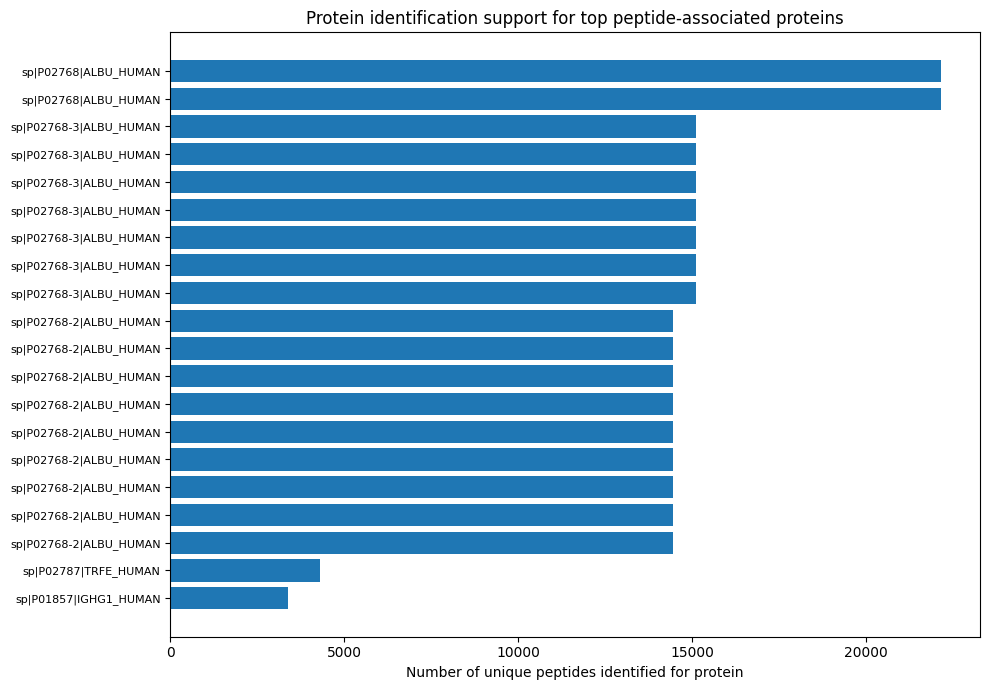

Saved: protein_identification_outputs\supporting_peptides_per_protein.png


In [11]:
plot_df = peptide_protein_table.dropna(subset=["main_protein"]).copy()
plot_df = plot_df.sort_values("num_total_peptides_identified_for_protein", ascending=False).head(20)

labels = plot_df["main_protein"].astype(str).tolist()
values = plot_df["num_total_peptides_identified_for_protein"].fillna(0).astype(int).tolist()

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
ax.barh(range(len(plot_df)), values)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Number of unique peptides identified for protein")
ax.set_title("Protein identification support for top peptide-associated proteins")
plt.tight_layout()
plot_path = OUTPUT_DIR / "supporting_peptides_per_protein.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## Step 11 — Bipartite graph

This graph directly shows the relationship between top peptides and their associated proteins.

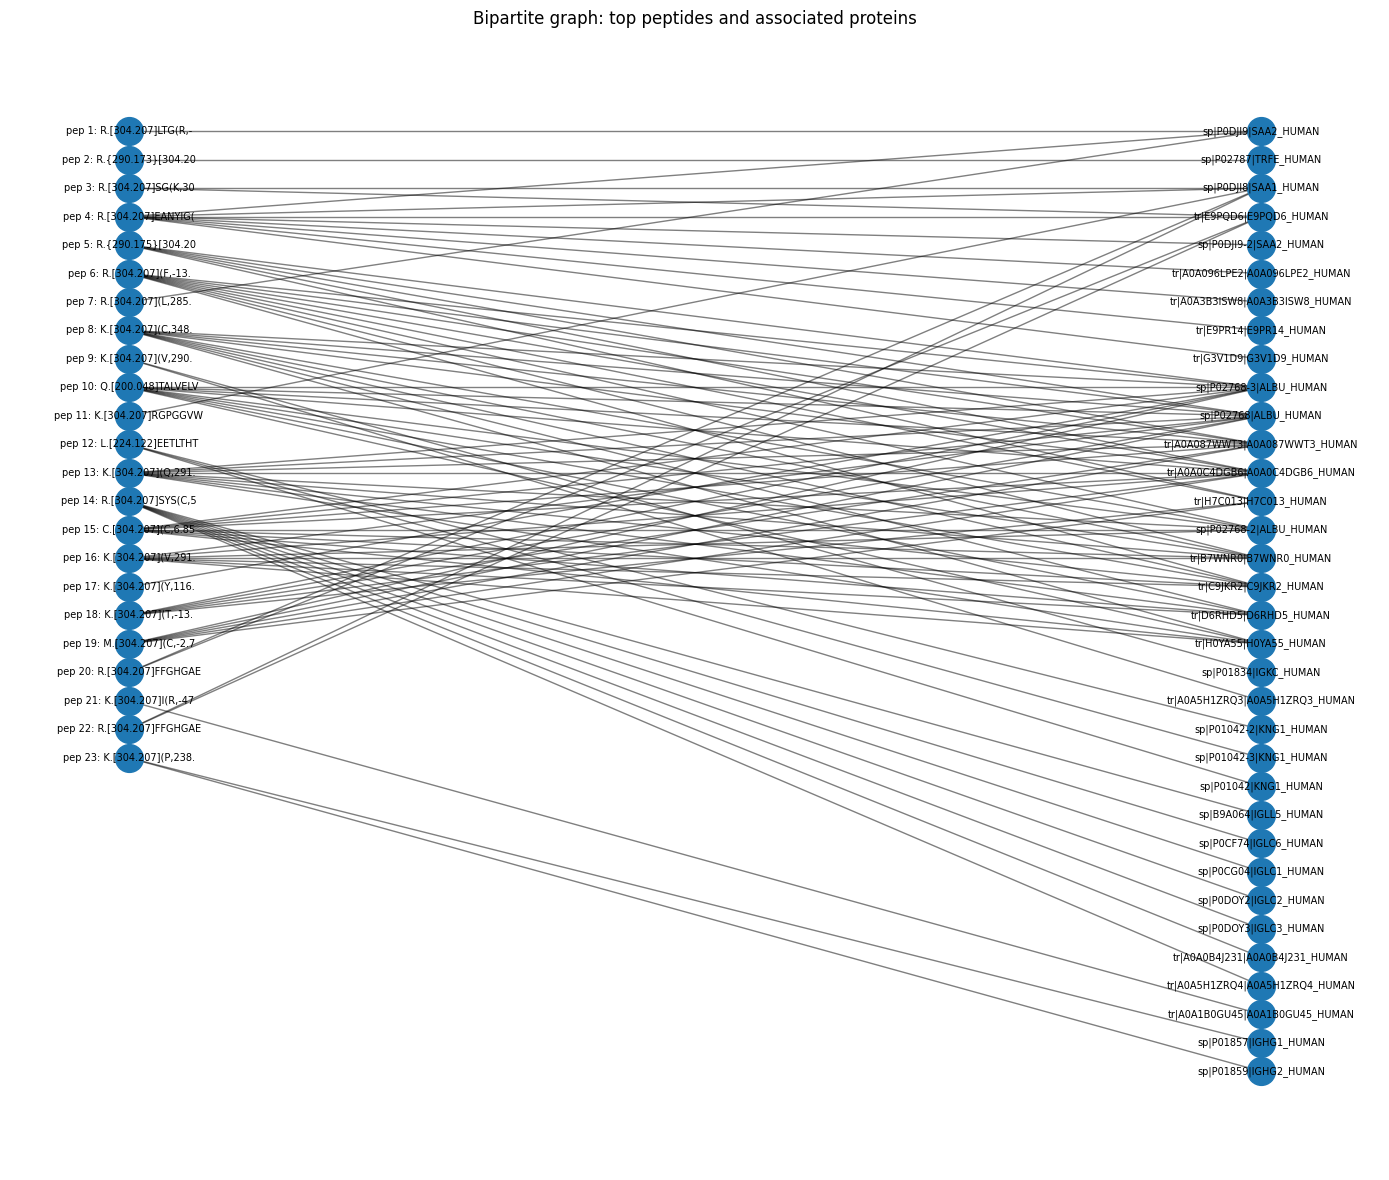

Saved: protein_identification_outputs\peptide_protein_bipartite_graph.png


In [12]:
if not HAS_NETWORKX:
    print("Skipping graph because networkx is not installed. Run `pip install networkx` if you want this figure.")
else:
    graph_rows = matched[[RAW_PEPTIDE_COL, "mapped_proteins", "top_peptide_rank"]].copy()
    graph_rows = graph_rows.explode("mapped_proteins").dropna(subset=["mapped_proteins"])
    graph_rows = graph_rows[graph_rows["mapped_proteins"].astype(str).str.len() > 0]
    graph_rows = graph_rows.sort_values("top_peptide_rank").head(100)

    G = nx.Graph()
    peptide_nodes = []
    protein_nodes = []

    for _, row in graph_rows.iterrows():
        pep = f"pep {int(row['top_peptide_rank'])}: {str(row[RAW_PEPTIDE_COL])[:18]}"
        prot = str(row["mapped_proteins"])
        G.add_node(pep, bipartite="peptide")
        G.add_node(prot, bipartite="protein")
        G.add_edge(pep, prot)
        peptide_nodes.append(pep)
        protein_nodes.append(prot)

    peptide_nodes = list(dict.fromkeys(peptide_nodes))
    protein_nodes = list(dict.fromkeys(protein_nodes))

    pos = {}
    for i, node in enumerate(peptide_nodes):
        pos[node] = (0, -i)
    for i, node in enumerate(protein_nodes):
        pos[node] = (1, -i)

    fig, ax = plt.subplots(figsize=(14, max(6, 0.35 * max(len(peptide_nodes), len(protein_nodes)))))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5)
    nx.draw_networkx_nodes(G, pos, nodelist=peptide_nodes, node_size=400, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=protein_nodes, node_size=400, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    ax.set_title("Bipartite graph: top peptides and associated proteins")
    ax.axis("off")
    plt.tight_layout()
    graph_path = OUTPUT_DIR / "peptide_protein_bipartite_graph.png"
    plt.savefig(graph_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {graph_path}")

## Step 12 — Generate report-ready wording

Copy/adapt this text into the final report after checking the generated table and figures.

In [13]:
n_top = len(peptide_protein_table)
n_unique = int(peptide_protein_table["unique_mapping"].sum())
n_ambig = int((~peptide_protein_table["unique_mapping"]).sum())
n_supported = int((peptide_protein_table["other_peptides_same_protein_identified"] >= 1).sum())

report_text = f"""
Protein identification was assessed by linking the top peptide/variant features from the differential-abundance analysis to their associated protein accessions in the raw Variants TMT annotation table. For each of the {n_top} top peptides evaluated, we recorded the mapped protein accession, whether the peptide mapped uniquely to one protein, and how many additional peptides from the same protein were identified in the dataset.

Among the evaluated top peptides, {n_unique} mapped uniquely to a single protein and {n_ambig} had ambiguous mappings to multiple proteins or no detected protein mapping. Proteins supported by uniquely mapped peptides and additional peptides from the same protein were treated as stronger protein identifications. In this analysis, {n_supported} top peptide-associated proteins had at least one other peptide identified from the same protein. Peptides mapping to multiple proteins were interpreted more cautiously because their abundance signal cannot be assigned confidently to only one protein.

The peptide-protein identification table and the supporting-peptides-per-protein plot provide evidence for the protein assignments used in the downstream protein-level interpretation.
""".strip()

print(report_text)
with open(OUTPUT_DIR / "protein_identification_report_text.txt", "w") as f:
    f.write(report_text + "")

Protein identification was assessed by linking the top peptide/variant features from the differential-abundance analysis to their associated protein accessions in the raw Variants TMT annotation table. For each of the 50 top peptides evaluated, we recorded the mapped protein accession, whether the peptide mapped uniquely to one protein, and how many additional peptides from the same protein were identified in the dataset.

Among the evaluated top peptides, 11 mapped uniquely to a single protein and 39 had ambiguous mappings to multiple proteins or no detected protein mapping. Proteins supported by uniquely mapped peptides and additional peptides from the same protein were treated as stronger protein identifications. In this analysis, 50 top peptide-associated proteins had at least one other peptide identified from the same protein. Peptides mapping to multiple proteins were interpreted more cautiously because their abundance signal cannot be assigned confidently to only one protein.

T